In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load raw predictions from the most recent experiment
# Update this path to your experiment folder
experiment_folder = Path("C:\git\PhysicalAdverserialProj\paper_experiments\experiment_results_2025-12-28_18_09_06")
# experiment_folder = Path("paper_experiments/experiment_results_YYYY-MM-DD_HH_MM_SS")

data_folder = experiment_folder / "data"

# Load the raw predictions CSV
raw_pred_path = data_folder / "raw_predictions.csv"

raw_predictions_df = pd.read_csv(raw_pred_path)
print(f"✓ Loaded raw predictions: {len(raw_predictions_df):,} rows")
print(f"  Columns: {list(raw_predictions_df.columns)}")


✓ Loaded raw predictions: 198,000 rows
  Columns: ['approach', 'patch_idx', 'patch_name', 'pose_idx', 'frame_idx', 'angle', 'distance', 'model', 'success', 'predicted_class']


In [18]:
raw_predictions_df_orig = raw_predictions_df.copy()
approachs_to_investigate = {
"CAPAA":"CAPAA",
"Patch_rejuv": "Patch_rejuv",
"Patch" : "Patch"
}
raw_predictions_df = raw_predictions_df[raw_predictions_df['approach'].apply(lambda x: x in approachs_to_investigate.keys())]
raw_predictions_df['approach'] = raw_predictions_df['approach'].apply(lambda x: approachs_to_investigate[x])

In [19]:
# Preview the data
print("Data Preview:")
print(raw_predictions_df.head(20).to_string())

print(f"\n\nUnique values:")
print(f"  Approaches: {raw_predictions_df['approach'].unique()}")
print(f"  Models: {raw_predictions_df['model'].unique()}")
print(f"  Poses: {sorted(raw_predictions_df['pose_idx'].unique()) if 'pose_idx' in raw_predictions_df.columns else 'N/A'}")
print(f"  Patches: {raw_predictions_df['patch_idx'].nunique()}")
print(f"  Frames per (approach, patch, pose): {raw_predictions_df.groupby(['approach', 'patch_idx', 'pose_idx', 'model']).size().iloc[0] if 'pose_idx' in raw_predictions_df.columns else 'N/A'}")

Data Preview:
   approach  patch_idx    patch_name  pose_idx  frame_idx      angle  distance            model  success predicted_class
0     CAPAA          0  img_0001.png         0          0  28.463798  1.128201     v1_inception    False      half track
1     CAPAA          0  img_0001.png         0          0  28.463798  1.128201        v1_resnet    False       amphibian
2     CAPAA          0  img_0001.png         0          0  28.463798  1.128201           v1_vgg     True        golfcart
3     CAPAA          0  img_0001.png         0          0  28.463798  1.128201           v1_vit    False         Model T
4     CAPAA          0  img_0001.png         0          0  28.463798  1.128201          v1_dino     True        golfcart
5     CAPAA          0  img_0001.png         0          0  28.463798  1.128201      v1_combined     True        golfcart
6     CAPAA          0  img_0001.png         0          0  28.463798  1.128201      v2_convnext    False      half track
7     CAPAA       

In [20]:
def compute_tensor_metrics(df, approach_name, model_name):
    """
    Build a tensor of shape (O, P, C) from the dataframe and compute metrics.
    
    Args:
        df: DataFrame with columns [pose_idx, patch_idx, frame_idx, model, success]
        approach_name: Name of the approach (CAPAA or Best Patch)
        model_name: Model to analyze (e.g., 'v1_combined', 'dino_standalone')
    
    Returns:
        Dictionary with all computed metrics
    """
    # Filter for this approach and model
    mask = (df['approach'] == approach_name) & (df['model'] == model_name)
    subset = df[mask].copy()
    
    if len(subset) == 0:
        return None
    
    # Get unique values
    poses = sorted(subset['pose_idx'].unique())
    patches = sorted(subset['patch_idx'].unique())
    captures = sorted(subset['frame_idx'].unique())
    
    O, P, C = len(poses), len(patches), len(captures)
    
    # Build the raw results tensor (O, P, C) - frame-level success
    results_tensor = np.zeros((O, P, C), dtype=float)
    
    for o_idx, pose in enumerate(poses):
        for p_idx, patch in enumerate(patches):
            for c_idx, capture in enumerate(captures):
                row_mask = (subset['pose_idx'] == pose) & (subset['patch_idx'] == patch) & (subset['frame_idx'] == capture)
                if row_mask.sum() > 0:
                    results_tensor[o_idx, p_idx, c_idx] = subset.loc[row_mask, 'success'].values[0]
    
    # Aggregate over captures using majority vote (>50% success)
    # res_binary shape: (O, P) - binary success per (pose, patch) pair
    capture_success_rate = results_tensor.mean(axis=2)  # (O, P) - average over captures
    res_binary = (capture_success_rate > 0.5).astype(float)  # Majority vote
    
    # Overall success rate and std
    overall_success = res_binary.mean() * 100
    overall_std = res_binary.std() * 100
    
    # Patch Success Rate (paper-consistent): Find best pose, report its success rate across patches
    success_per_pose = res_binary.mean(axis=1)  # (O,) - average over patches for each pose
    best_pose_idx = success_per_pose.argmax()
    best_pose = poses[best_pose_idx]
    patch_success_rate = success_per_pose[best_pose_idx] * 100
    
    # Pose Success Rate: Find best patch, report its success rate across poses
    success_per_patch = res_binary.mean(axis=0)  # (P,) - average over poses for each patch
    best_patch_idx = success_per_patch.argmax()
    best_patch = patches[best_patch_idx]
    pose_success_rate = success_per_patch[best_patch_idx] * 100
    
    return {
        'approach': approach_name,
        'model': model_name,
        'tensor_shape': (O, P, C),
        'overall_success': overall_success,
        'overall_std': overall_std,
        'patch_success_rate': patch_success_rate,
        'best_pose_idx': best_pose,
        'pose_success_rate': pose_success_rate,
        'best_patch_idx': best_patch,
        'res_binary': res_binary,
        'results_tensor': results_tensor,
        'success_per_pose': success_per_pose * 100,
        'success_per_patch': success_per_patch * 100,
        'poses': poses,
        'patches': patches
    }

print("✓ Tensor analysis function defined")

✓ Tensor analysis function defined


In [21]:
# Define models to analyze
models_to_analyze = [
    'v1_combined',
    'v2_combined', 
    'dino_standalone'
]

model_display_names = {
    'v1_combined': 'V1 Ensemble (Seen)',
    'v2_combined': 'V2 Ensemble (Unseen)',
    'dino_standalone': 'DINOv2 (Unseen-Strong)'
}

# Get approach names from the approachs_to_investigate dict (display names)
approaches_list = list(approachs_to_investigate.values())
print(f"Approaches to analyze: {approaches_list}")

# Check if multi-pose mode
if 'pose_idx' not in raw_predictions_df.columns:
    print("⚠️ Single-pose mode detected. This analysis requires multi-pose data.")
else:
    print("="*100)
    print("TENSOR-BASED SUCCESS RATE ANALYSIS")
    print("Structure: Poses (O) × Patches (P) × Captures (C)")
    print("="*100)
    
    # Get available models in the data
    available_models = raw_predictions_df['model'].unique()
    print(f"\nAvailable models in data: {list(available_models)}")
    
    # Filter to models that exist
    models_to_analyze = [m for m in models_to_analyze if m in available_models]
    print(f"Models to analyze: {models_to_analyze}")
    
    # Compute metrics for each approach and model
    all_metrics = []
    
    for model_name in models_to_analyze:
        for approach_name in approaches_list:
            metrics = compute_tensor_metrics(raw_predictions_df, approach_name, model_name)
            if metrics:
                all_metrics.append(metrics)
    
    if all_metrics:
        print(f"\nTensor Shape: {all_metrics[0]['tensor_shape']} (Poses × Patches × Captures)")
        print(f"  - {all_metrics[0]['tensor_shape'][0]} poses")
        print(f"  - {all_metrics[0]['tensor_shape'][1]} patches (per approach)")
        print(f"  - {all_metrics[0]['tensor_shape'][2]} captures per (pose, patch) pair")

Approaches to analyze: ['CAPAA', 'Patch_rejuv', 'Patch']
TENSOR-BASED SUCCESS RATE ANALYSIS
Structure: Poses (O) × Patches (P) × Captures (C)

Available models in data: ['v1_inception', 'v1_resnet', 'v1_vgg', 'v1_vit', 'v1_dino', 'v1_combined', 'v2_convnext', 'v2_efficientnet', 'v2_mobilenet', 'v2_swin', 'v2_combined', 'dino_standalone']
Models to analyze: ['v1_combined', 'v2_combined', 'dino_standalone']

Tensor Shape: (5, 11, 100) (Poses × Patches × Captures)
  - 5 poses
  - 11 patches (per approach)
  - 100 captures per (pose, patch) pair


In [22]:
# Display Overall Success Rates
print("\n" + "-"*100)
print("OVERALL SUCCESS RATES (res_binary.mean() ± std)")
print("-"*100)

# Build dynamic header
header = f"{'Model':<30}"
for approach in approaches_list:
    header += f" {approach:>20}"
header += f" {'Winner':>15}"
print(header)
print("-"*100)

for model_name in models_to_analyze:
    display_name = model_display_names.get(model_name, model_name)
    
    # Get metrics for all approaches
    approach_metrics = {a: next((m for m in all_metrics if m['approach'] == a and m['model'] == model_name), None) 
                        for a in approaches_list}
    
    # Skip if no approaches have data
    valid_approaches = {k: v for k, v in approach_metrics.items() if v is not None}
    if not valid_approaches:
        continue
    
    row = f"{display_name:<30}"
    best_approach = None
    best_value = -1
    
    for approach in approaches_list:
        m = approach_metrics.get(approach)
        if m:
            row += f" {m['overall_success']:.1f}% ± {m['overall_std']:.1f}%".rjust(20)
            if m['overall_success'] > best_value:
                best_value = m['overall_success']
                best_approach = approach
        else:
            row += " N/A".rjust(20)
    
    row += f" {best_approach:>15}" if best_approach else " N/A".rjust(15)
    print(row)


----------------------------------------------------------------------------------------------------
OVERALL SUCCESS RATES (res_binary.mean() ± std)
----------------------------------------------------------------------------------------------------
Model                                         CAPAA          Patch_rejuv                Patch          Winner
----------------------------------------------------------------------------------------------------
V1 Ensemble (Seen)                   74.5% ± 43.6%       100.0% ± 0.0%       100.0% ± 0.0%     Patch_rejuv
V2 Ensemble (Unseen)                 40.0% ± 49.0%       76.4% ± 42.5%       100.0% ± 0.0%           Patch
DINOv2 (Unseen-Strong)               85.5% ± 35.3%       100.0% ± 0.0%       94.5% ± 22.7%     Patch_rejuv


In [23]:
# Display Patch Success Rate (Paper-Consistent)
print("\n" + "-"*100)
print("PATCH SUCCESS RATE (Paper-Consistent: Best Pose's Success Rate Across Patches)")
print("-"*100)

# Build dynamic header
header = f"{'Model':<30}"
for approach in approaches_list:
    header += f" {approach:>25}"
header += f" {'Winner':>15}"
print(header)
print("-"*100)

for model_name in models_to_analyze:
    display_name = model_display_names.get(model_name, model_name)
    
    # Get metrics for all approaches
    approach_metrics = {a: next((m for m in all_metrics if m['approach'] == a and m['model'] == model_name), None) 
                        for a in approaches_list}
    
    valid_approaches = {k: v for k, v in approach_metrics.items() if v is not None}
    if not valid_approaches:
        continue
    
    row = f"{display_name:<30}"
    best_approach = None
    best_value = -1
    
    for approach in approaches_list:
        m = approach_metrics.get(approach)
        if m:
            val_str = f"{m['patch_success_rate']:.1f}% (pose {m['best_pose_idx']})"
            row += f" {val_str:>25}"
            if m['patch_success_rate'] > best_value:
                best_value = m['patch_success_rate']
                best_approach = approach
        else:
            row += " N/A".rjust(25)
    
    row += f" {best_approach:>15}" if best_approach else " N/A".rjust(15)
    print(row)


----------------------------------------------------------------------------------------------------
PATCH SUCCESS RATE (Paper-Consistent: Best Pose's Success Rate Across Patches)
----------------------------------------------------------------------------------------------------
Model                                              CAPAA               Patch_rejuv                     Patch          Winner
----------------------------------------------------------------------------------------------------
V1 Ensemble (Seen)                       100.0% (pose 4)           100.0% (pose 0)           100.0% (pose 0)           CAPAA
V2 Ensemble (Unseen)                      90.9% (pose 4)           100.0% (pose 0)           100.0% (pose 0)     Patch_rejuv
DINOv2 (Unseen-Strong)                   100.0% (pose 0)           100.0% (pose 0)           100.0% (pose 0)           CAPAA


In [24]:
# Display Pose Success Rate
print("\n" + "-"*100)
print("POSE SUCCESS RATE (Best Patch's Success Rate Across Poses)")
print("-"*100)

# Build dynamic header
header = f"{'Model':<30}"
for approach in approaches_list:
    header += f" {approach:>25}"
header += f" {'Winner':>15}"
print(header)
print("-"*100)

for model_name in models_to_analyze:
    display_name = model_display_names.get(model_name, model_name)
    
    # Get metrics for all approaches
    approach_metrics = {a: next((m for m in all_metrics if m['approach'] == a and m['model'] == model_name), None) 
                        for a in approaches_list}
    
    valid_approaches = {k: v for k, v in approach_metrics.items() if v is not None}
    if not valid_approaches:
        continue
    
    row = f"{display_name:<30}"
    best_approach = None
    best_value = -1
    
    for approach in approaches_list:
        m = approach_metrics.get(approach)
        if m:
            val_str = f"{m['pose_success_rate']:.1f}% (patch {m['best_patch_idx']})"
            row += f" {val_str:>25}"
            if m['pose_success_rate'] > best_value:
                best_value = m['pose_success_rate']
                best_approach = approach
        else:
            row += " N/A".rjust(25)
    
    row += f" {best_approach:>15}" if best_approach else " N/A".rjust(15)
    print(row)


----------------------------------------------------------------------------------------------------
POSE SUCCESS RATE (Best Patch's Success Rate Across Poses)
----------------------------------------------------------------------------------------------------
Model                                              CAPAA               Patch_rejuv                     Patch          Winner
----------------------------------------------------------------------------------------------------
V1 Ensemble (Seen)                      100.0% (patch 5)          100.0% (patch 0)          100.0% (patch 0)           CAPAA
V2 Ensemble (Unseen)                     60.0% (patch 5)          100.0% (patch 4)          100.0% (patch 0)     Patch_rejuv
DINOv2 (Unseen-Strong)                  100.0% (patch 0)          100.0% (patch 0)          100.0% (patch 1)           CAPAA


In [25]:
# Detailed breakdown per pose
print("\n" + "="*100)
print("DETAILED BREAKDOWN: Success Rate Per Pose (averaged over patches)")
print("="*100)

for model_name in models_to_analyze:
    display_name = model_display_names.get(model_name, model_name)
    
    # Get metrics for all approaches
    approach_metrics = {a: next((m for m in all_metrics if m['approach'] == a and m['model'] == model_name), None) 
                        for a in approaches_list}
    
    valid_approaches = {k: v for k, v in approach_metrics.items() if v is not None}
    if not valid_approaches:
        continue
    
    print(f"\n{display_name}:")
    
    # Build header
    header = f"  {'Pose':<10}"
    for approach in approaches_list:
        if approach_metrics.get(approach):
            header += f" {approach:>15}"
    header += f" {'Winner':>12}"
    print(header)
    
    # Get number of poses from first valid approach
    first_metrics = list(valid_approaches.values())[0]
    n_poses = len(first_metrics['success_per_pose'])
    
    for pose_idx in range(n_poses):
        row = f"  Pose {pose_idx:<5}"
        best_approach = None
        best_rate = -1
        
        for approach in approaches_list:
            m = approach_metrics.get(approach)
            if m:
                rate = m['success_per_pose'][pose_idx]
                row += f" {rate:>14.1f}%"
                if rate > best_rate:
                    best_rate = rate
                    best_approach = approach
        
        # Shorten winner name if needed
        if best_approach:
            winner_short = best_approach[:10] if len(best_approach) > 10 else best_approach
            row += f" {winner_short:>12}"
        print(row)


DETAILED BREAKDOWN: Success Rate Per Pose (averaged over patches)

V1 Ensemble (Seen):
  Pose                 CAPAA     Patch_rejuv           Patch       Winner
  Pose 0               72.7%          100.0%          100.0%   Patch_reju
  Pose 1               72.7%          100.0%          100.0%   Patch_reju
  Pose 2               36.4%          100.0%          100.0%   Patch_reju
  Pose 3               90.9%          100.0%          100.0%   Patch_reju
  Pose 4              100.0%          100.0%          100.0%        CAPAA

V2 Ensemble (Unseen):
  Pose                 CAPAA     Patch_rejuv           Patch       Winner
  Pose 0                0.0%          100.0%          100.0%   Patch_reju
  Pose 1               27.3%          100.0%          100.0%   Patch_reju
  Pose 2                0.0%            9.1%          100.0%        Patch
  Pose 3               81.8%           72.7%          100.0%        Patch
  Pose 4               90.9%          100.0%          100.0%   Patch_reju



In [26]:
# Summary Table
print("\n" + "="*100)
print("SUMMARY TABLE FOR PAPER")
print("="*100)

summary_data = []
for model_name in models_to_analyze:
    display_name = model_display_names.get(model_name, model_name)
    
    # Get metrics for all approaches
    approach_metrics = {a: next((m for m in all_metrics if m['approach'] == a and m['model'] == model_name), None) 
                        for a in approaches_list}
    
    valid_approaches = {k: v for k, v in approach_metrics.items() if v is not None}
    if not valid_approaches:
        continue
    
    row_data = {'Model': display_name}
    
    # Add columns for each approach
    best_approach = None
    best_patch_sr = -1
    for approach in approaches_list:
        m = approach_metrics.get(approach)
        if m:
            row_data[f'{approach} Overall'] = f"{m['overall_success']:.1f}%"
            row_data[f'{approach} Std'] = f"±{m['overall_std']:.1f}%"
            row_data[f'{approach} Patch SR'] = f"{m['patch_success_rate']:.1f}%"
            if m['patch_success_rate'] > best_patch_sr:
                best_patch_sr = m['patch_success_rate']
                best_approach = approach
        else:
            row_data[f'{approach} Overall'] = "N/A"
            row_data[f'{approach} Std'] = "N/A"
            row_data[f'{approach} Patch SR'] = "N/A"
    
    row_data['Winner'] = best_approach if best_approach else "N/A"
    summary_data.append(row_data)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


SUMMARY TABLE FOR PAPER
                 Model CAPAA Overall CAPAA Std CAPAA Patch SR Patch_rejuv Overall Patch_rejuv Std Patch_rejuv Patch SR Patch Overall Patch Std Patch Patch SR      Winner
    V1 Ensemble (Seen)         74.5%    ±43.6%         100.0%              100.0%           ±0.0%               100.0%        100.0%     ±0.0%         100.0%       CAPAA
  V2 Ensemble (Unseen)         40.0%    ±49.0%          90.9%               76.4%          ±42.5%               100.0%        100.0%     ±0.0%         100.0% Patch_rejuv
DINOv2 (Unseen-Strong)         85.5%    ±35.3%         100.0%              100.0%           ±0.0%               100.0%         94.5%    ±22.7%         100.0%       CAPAA


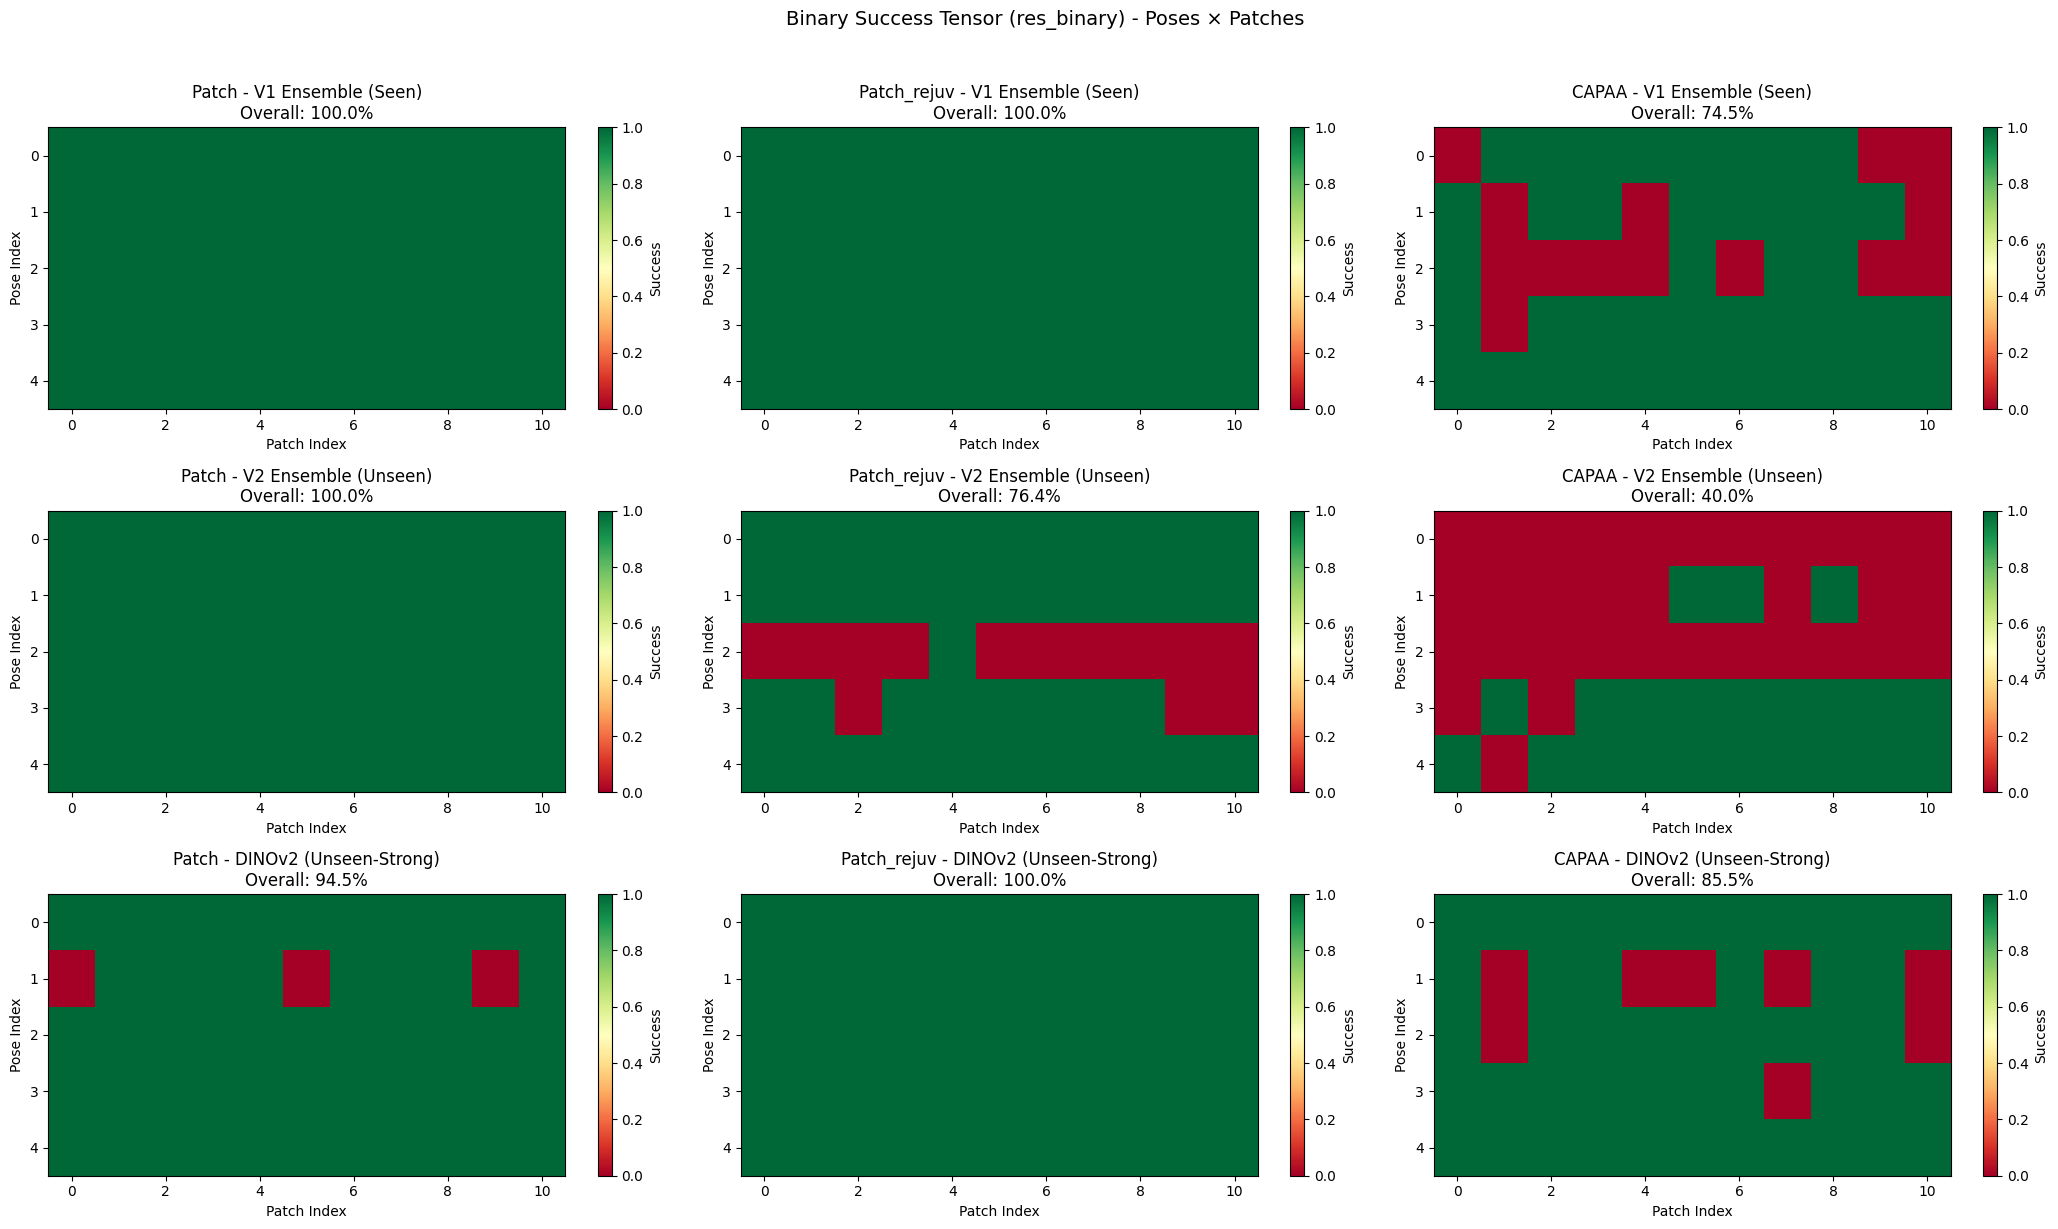

In [27]:
# Visualize res_binary as heatmap
import matplotlib.pyplot as plt

# Get approaches that actually have data
available_approaches = list(set(m['approach'] for m in all_metrics))
n_approaches = len(available_approaches)

fig, axes = plt.subplots(len(models_to_analyze), n_approaches, figsize=(7*n_approaches, 4*len(models_to_analyze)))
if len(models_to_analyze) == 1:
    axes = axes.reshape(1, -1)
if n_approaches == 1:
    axes = axes.reshape(-1, 1)

for idx, model_name in enumerate(models_to_analyze):
    display_name = model_display_names.get(model_name, model_name)
    
    for col_idx, approach in enumerate(available_approaches):
        m = next((m for m in all_metrics if m['approach'] == approach and m['model'] == model_name), None)
        
        if m:
            im = axes[idx, col_idx].imshow(m['res_binary'], cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
            axes[idx, col_idx].set_title(f"{approach} - {display_name}\nOverall: {m['overall_success']:.1f}%")
            axes[idx, col_idx].set_xlabel('Patch Index')
            axes[idx, col_idx].set_ylabel('Pose Index')
            plt.colorbar(im, ax=axes[idx, col_idx], label='Success')

plt.suptitle('Binary Success Tensor (res_binary) - Poses × Patches', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Interactive Plotly Heatmaps
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Get approaches that actually have data
available_approaches = list(set(m['approach'] for m in all_metrics))
n_approaches = len(available_approaches)

# Create subplots - n_approaches columns x n_models rows
fig = make_subplots(
    rows=len(models_to_analyze), 
    cols=n_approaches,
    subplot_titles=[f"{model_display_names.get(m, m)} - {approach}" 
                    for m in models_to_analyze 
                    for approach in available_approaches],
    horizontal_spacing=0.1,
    vertical_spacing=0.15
)

for idx, model_name in enumerate(models_to_analyze):
    display_name = model_display_names.get(model_name, model_name)
    row = idx + 1
    
    for col_idx, approach in enumerate(available_approaches):
        m = next((m for m in all_metrics if m['approach'] == approach and m['model'] == model_name), None)
        
        if m:
            fig.add_trace(
                go.Heatmap(
                    z=m['res_binary'],
                    x=[f"P{i}" for i in range(m['res_binary'].shape[1])],
                    y=[f"Pose {i}" for i in range(m['res_binary'].shape[0])],
                    colorscale='RdYlGn',
                    zmin=0, zmax=1,
                    showscale=(idx == 0 and col_idx == 0),
                    hovertemplate='Pose: %{y}<br>Patch: %{x}<br>Success: %{z}<extra></extra>',
                    name=f'{approach} {display_name}'
                ),
                row=row, col=col_idx + 1
            )

fig.update_layout(
    title_text='Binary Success Tensor (res_binary) - Interactive View<br><sup>Hover for details | Green=Success, Red=Failure</sup>',
    height=350 * len(models_to_analyze),
    width=400 * max(n_approaches, 2),
)

# Update axes labels
for i in range(len(models_to_analyze)):
    for j in range(n_approaches):
        fig.update_xaxes(title_text='Patch Index', row=i+1, col=j+1)
    fig.update_yaxes(title_text='Pose Index', row=i+1, col=1)

fig.show()

# Save interactive HTML
fig.write_html("tensor_heatmap_interactive.html")
print("✓ Saved interactive heatmap to tensor_heatmap_interactive.html")

✓ Saved interactive heatmap to tensor_heatmap_interactive.html


## 📊 Consistency Analysis: Standard Deviation Across Captures

Instead of binary success (majority vote), here we show the **standard deviation of success rates across the 100 captures** for each (pose, patch) combination.

- **Low std (blue)**: Consistent results - attack either always works or always fails
- **High std (red)**: Inconsistent results - attack success varies across captures

In [29]:
# Compute std across captures for each (pose, patch) pair
# This shows consistency - low std = consistent results, high std = variable results

std_metrics = []

for model_name in models_to_analyze:
    for approach in approaches_list:
        m = next((m for m in all_metrics if m['approach'] == approach and m['model'] == model_name), None)
        if m:
            # results_tensor shape is (O, P, C) - compute std across captures (axis=2)
            std_across_captures = m['results_tensor'].std(axis=2)  # Shape: (O, P)
            mean_across_captures = m['results_tensor'].mean(axis=2)  # Shape: (O, P)
            
            std_metrics.append({
                'approach': approach,
                'model': model_name,
                'std_tensor': std_across_captures,
                'mean_tensor': mean_across_captures,
                'avg_std': std_across_captures.mean(),
                'max_std': std_across_captures.max(),
                'min_std': std_across_captures.min()
            })

# Summary of consistency
print("="*100)
print("CONSISTENCY ANALYSIS: Std of Success Across Captures")
print("="*100)

# Build dynamic header based on available approaches
available_approaches = list(set(m['approach'] for m in std_metrics))
header = f"{'Model':<30}"
for approach in available_approaches:
    header += f" {approach+' Std':>18}"
header += f" {'More Consistent':>18}"
print(header)
print("-"*100)

for model_name in models_to_analyze:
    display_name = model_display_names.get(model_name, model_name)
    
    # Get std metrics for available approaches
    approach_std = {a: next((m for m in std_metrics if m['approach'] == a and m['model'] == model_name), None) 
                    for a in available_approaches}
    
    valid_approaches = {k: v for k, v in approach_std.items() if v is not None}
    if not valid_approaches:
        continue
    
    row = f"{display_name:<30}"
    best_approach = None
    best_std = float('inf')
    
    for approach in available_approaches:
        m = approach_std.get(approach)
        if m:
            row += f" {m['avg_std']:>17.3f}"
            if m['avg_std'] < best_std:
                best_std = m['avg_std']
                best_approach = approach
        else:
            row += " N/A".rjust(18)
    
    row += f" {best_approach:>18}" if best_approach else " N/A".rjust(18)
    print(row)

CONSISTENCY ANALYSIS: Std of Success Across Captures
Model                                   Patch Std    Patch_rejuv Std          CAPAA Std    More Consistent
----------------------------------------------------------------------------------------------------
V1 Ensemble (Seen)                         0.008             0.000             0.147        Patch_rejuv
V2 Ensemble (Unseen)                       0.071             0.177             0.195              Patch
DINOv2 (Unseen-Strong)                     0.065             0.136             0.132              Patch


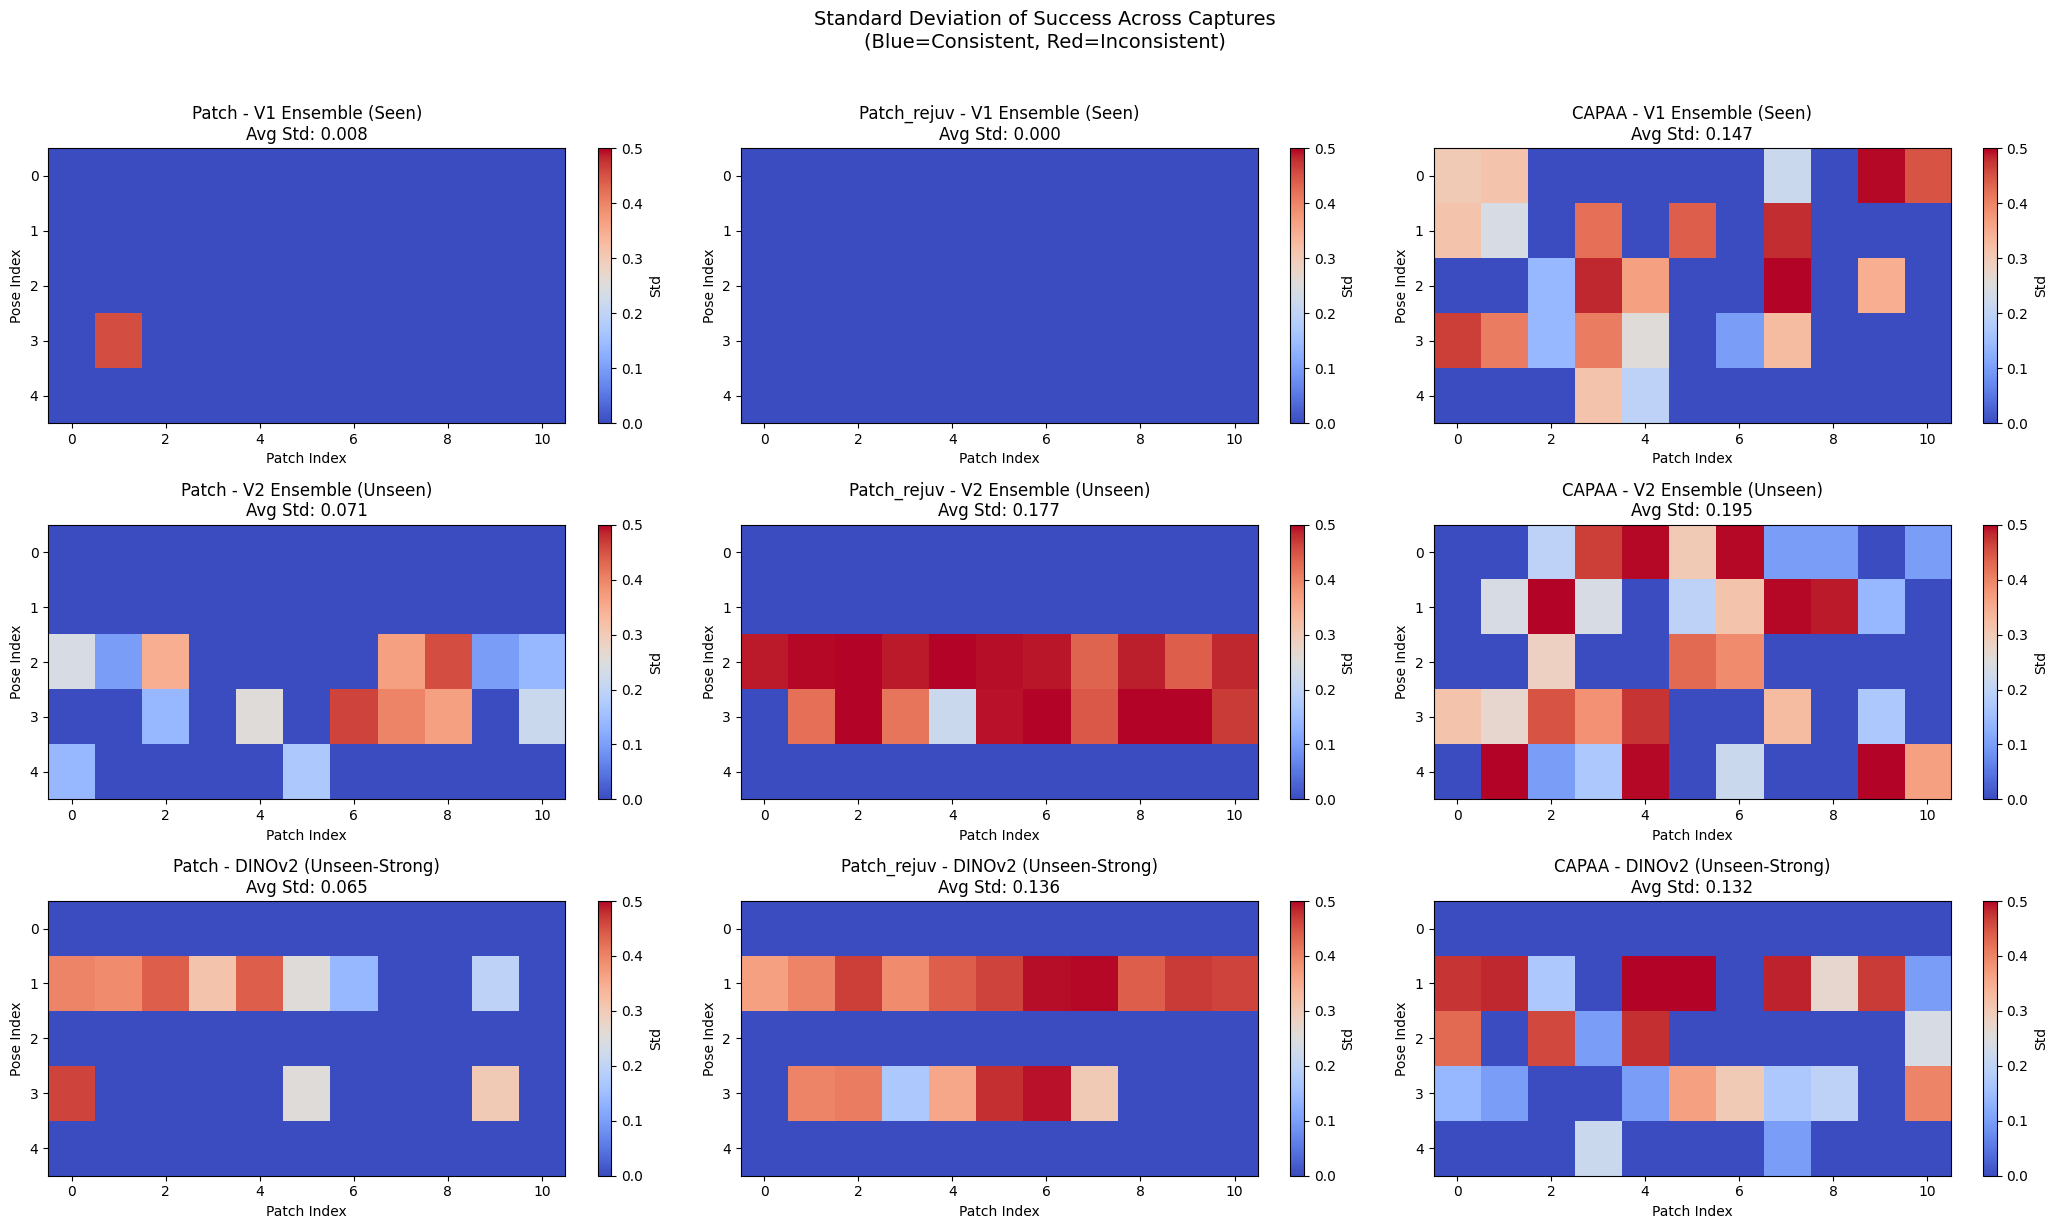

In [30]:
# Matplotlib: Std heatmaps (static)
# Get approaches that actually have data
available_approaches = list(set(m['approach'] for m in std_metrics))
n_approaches = len(available_approaches)

fig, axes = plt.subplots(len(models_to_analyze), n_approaches, figsize=(7*n_approaches, 4*len(models_to_analyze)))
if len(models_to_analyze) == 1:
    axes = axes.reshape(1, -1)
if n_approaches == 1:
    axes = axes.reshape(-1, 1)

for idx, model_name in enumerate(models_to_analyze):
    display_name = model_display_names.get(model_name, model_name)
    
    for col_idx, approach in enumerate(available_approaches):
        m = next((m for m in std_metrics if m['approach'] == approach and m['model'] == model_name), None)
        
        if m:
            im = axes[idx, col_idx].imshow(m['std_tensor'], cmap='coolwarm', vmin=0, vmax=0.5, aspect='auto')
            axes[idx, col_idx].set_title(f"{approach} - {display_name}\nAvg Std: {m['avg_std']:.3f}")
            axes[idx, col_idx].set_xlabel('Patch Index')
            axes[idx, col_idx].set_ylabel('Pose Index')
            plt.colorbar(im, ax=axes[idx, col_idx], label='Std')

plt.suptitle('Standard Deviation of Success Across Captures\n(Blue=Consistent, Red=Inconsistent)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [31]:
# Plotly: Interactive std heatmaps
from plotly.subplots import make_subplots
import os

# Get approaches that actually have data
available_approaches = list(set(m['approach'] for m in std_metrics))
n_approaches = len(available_approaches)

fig = make_subplots(
    rows=len(models_to_analyze), cols=n_approaches,
    subplot_titles=[f"{approach} - {model_display_names.get(m, m)}" 
                    for m in models_to_analyze for approach in available_approaches],
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

for idx, model_name in enumerate(models_to_analyze):
    display_name = model_display_names.get(model_name, model_name)
    row = idx + 1
    
    for col_idx, approach in enumerate(available_approaches):
        m = next((m for m in std_metrics if m['approach'] == approach and m['model'] == model_name), None)
        
        if m:
            fig.add_trace(
                go.Heatmap(
                    z=m['std_tensor'],
                    colorscale='RdBu_r',
                    zmin=0, zmax=0.5,
                    colorbar=dict(title='Std', x=1.0) if (idx == 0 and col_idx == n_approaches - 1) else None,
                    showscale=(idx == 0 and col_idx == n_approaches - 1),
                    hovertemplate='Pose: %{y}<br>Patch: %{x}<br>Std: %{z:.3f}<extra></extra>'
                ),
                row=row, col=col_idx + 1
            )

fig.update_layout(
    title='Interactive: Standard Deviation Across Captures (Hover for details)',
    height=350 * len(models_to_analyze),
    width=350 * max(n_approaches, 2),
    showlegend=False
)

fig.update_xaxes(title_text='Patch Index')
fig.update_yaxes(title_text='Pose Index')

fig.show()

In [32]:
# Debug cell - clear when done
